Exercises precipitation
=====
## Tutorial: Interpolate missing values

---

Note: I have used the material by [**Jesús Casado Rodríguez**](https://github.com/casadoj) for this tutorial. If you ever had the time, please check out his [repository](https://github.com/casadoj/Clases.git) for more material.

---

The figure shows the location of 11 precipitation gauges in a research
watershed. Measurements are missing at gauge F for a rain storm. Use
the records from the other gauges (shown in the following table) to
fill the gap in the rainfall amount in gauge F.

<img src="image/RainGauges.png" alt="Mountain View" style="width:300px">

The file *RainfallData_Exercise_001.csv* contains the rainfall data.

| Gauge | X      | Y       | Average Annual Precip. (mm) | Measured Storm Precip. (mm) |
|------|--------|---------|-----------------------------|-----------------------------|
| C    | 385014 | 4778553 | 1404                        | 11.6                        |
| D    | 389634 | 4779045 | 1433                        | 14.8                        |
| E    | 380729 | 4775518 | 1665                        | 13.3                        |
| F    | 387259 | 4776670 | 1137                        | -                           |
| G    | 389380 | 4776484 | 1235                        | 12.3                        |
| H    | 382945 | 4772356 | 1114                        | 11.5                        |
| I    | 386399 | 4771795 | 1101                        | 11.6                        |
| J    | 388397 | 4772419 | 1086                        | 11.2                        |
| K    | 389287 | 4771097 | 1010                        | 9.7                         |

#### Methods:
[1.1 The station-average method](#The-station-average-method)<br>
[1.2 The normal-ratio method](#The-normal-ration-method)<br>
[1.3 The inverse distance method](#The-inverse-distance-method)<br>

Missing data completion methods and interpolation methods are
both based in the following general interpolation equation:

$$\hat{p_o} = \sum_{i=1}^{n} w_i·p_i$$

Where $\hat{p_o}$ is the rainfall value to be filled or interpolated, $n$
is the number of gauges used to interpolate, $w_i$ and $p_i$ are the
weighting factor and the rainfall value in each of those gauges.
The weighting is determined in each case by the way we think it is appropriate
to relate the unknown values to the known measurements.

In [1]:
import numpy as np

import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns
sns.set()
sns.set_context('notebook')

### Import data
*Pandas* is often the go-to library for dealing with spreadsheets and data because it provides:
1. **Easy data import**: Read CSV, Excel, JSON, SQL databases with simple functions like pd.read_csv()
2. **DataFrame structure**: 2D labeled data structure with rows and columns, similar to Excel spreadsheets
3. **Powerful indexing**: Access data by position (.iloc) or labels (.loc) with intuitive syntax
4. **Built-in data analysis**: Statistical functions (mean, std, describe), grouping, pivoting
5. **Data cleaning**: Handle missing values, data types, duplicates with specialized methods
6. **Integration**: Works seamlessly with NumPy for calculations and Matplotlib/Seaborn for visualization
7. **Performance**: Optimized C code under the hood for fast operations on large datasets
8. **Flexibility**: Easy to reshape, merge, join, and transform data for analysis workflows
Now import data using *pandas* and save it in an object (*data frame* using pandas terminology).

In [2]:
data1 = pd.read_csv('RainfallData_Exercise_001.csv', index_col=0)

*DataFrames* have several built-in attributes that provide useful information about the data structure. For example, you can access the dimensions of the table (`shape`), the total number of elements (`size`), the row and column labels (`index` and `columns`), or convert the data to a *NumPy array* (`values`).
To access an attribute of a `DataFrame` object (e.g., `data1`), use the syntax: `data1.attribute`, where `attribute` is the specific property you want to retrieve (e.g., `shape`, `size`, `index`, `columns`, `values`).

In [3]:
# dimension
print(f"Shape of dataframe: {data1.shape}")
# number of elements
print(f"Number of elements: {data1.size}")
# row names
print(f"Row names: {data1.index}")
# column names
print(f"Column names: {data1.columns}")

Shape of dataframe: (11, 4)
Number of elements: 44
Row names: Index(['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K'], dtype='object', name='Gage')
Column names: Index(['X', 'Y', 'Average Annual Precip. (mm)', 'Measured Storm Precip. (mm)'], dtype='object')


**Exercise: Exploring DataFrame Methods**

In addition to attributes, pandas DataFrames provide numerous methods for data analysis and manipulation. These methods are essential tools for understanding and working with your dataset.

**Key Methods to Explore:**
- `describe()`: Provides comprehensive statistical summary (count, mean, std, min, max, quartiles)
- `mean()`: Calculates the arithmetic mean of numerical columns
- `head(n)`: Shows the first n rows (default n=5)
- `tail(n)`: Shows the last n rows (default n=5)
- `info()`: Displays DataFrame information (data types, memory usage, non-null counts)

**Syntax:** To apply a method to a DataFrame, use: `DataFrame.method_name()`

**Note:** Methods with parentheses `()` perform actions, while attributes without parentheses provide information.

In [4]:
# Print a summary of the files
print(f"{data1.describe()}")
# Print a mean of values
print(f"{round(data1.mean(), 0)}")
# Print the first two rows
print(f"{data1.head(n=2)}")

                   X             Y  Average Annual Precip. (mm)  \
count      11.000000  1.100000e+01                    11.000000   
mean   386379.272727  4.775873e+06                  1273.636364   
std      2983.076804  3.550817e+03                   204.304808   
min    380729.000000  4.771097e+06                  1010.000000   
25%    384218.000000  4.772388e+06                  1107.500000   
50%    387259.000000  4.776484e+06                  1235.000000   
75%    388842.000000  4.778719e+06                  1418.500000   
max    389634.000000  4.781780e+06                  1665.000000   

       Measured Storm Precip. (mm)  
count                    10.000000  
mean                     12.260000  
std                       1.536374  
min                       9.700000  
25%                      11.525000  
50%                      11.900000  
75%                      13.050000  
max                      14.800000  
X                               386379.0
Y                     

**Data Selection and Extraction**

To access specific data points or subsets from a DataFrame, you need to specify both row and column identifiers. pandas provides two powerful indexing methods for this purpose:

**Label-based indexing (`.loc`):**
- Uses row and column labels/names for selection
- More intuitive when working with meaningful row/column names
- Syntax: `DataFrame.loc[row_label, column_label]`

**Integer-based indexing (`.iloc`):**
- Uses integer positions (0-based indexing) for selection
- Useful when you know the position but not the label
- **Important:** Python uses 0-based indexing, so the first row/column is at position 0, not 1
- Syntax: `DataFrame.iloc[row_position, column_position]`

**Direct column access:** You can also access entire columns using bracket notation: `DataFrame['column_name']`

**Exercise:** In the next cell, practice these indexing methods by extracting specific data points and subsets from your DataFrame.
Extract using .loc

In [5]:
# Extract a single value using label-based indexing
data1.loc['A', 'Measured Storm Precip. (mm)']
# Extract all columns for row 'A' using label-based indexing
data1.loc['A', :]
# Extract specific column for multiple rows using label-based indexing
data1.loc[['A', 'C'], 'Average Annual Precip. (mm)']
# Extract using integer-based indexing (.iloc)
# Extract single value at position (0,0) - first row, first column
data1.iloc[0, 0]
# Extract all columns for the first row using integer-based indexing
data1.iloc[0, :]
# Extract second column (index 1) for rows 0 and 2 using integer-based indexing
data1.iloc[[0, 2], 1]
# Extract an entire column by its name using bracket notation
data1['Average Annual Precip. (mm)']

Gage
A    1373
B    1452
C    1404
D    1433
E    1665
F    1137
G    1235
H    1114
I    1101
J    1086
K    1010
Name: Average Annual Precip. (mm), dtype: int64

It is also easy to adjust the column names for them to be more representative, or even easy to use in coding.

In [6]:
# Simplify column names
# d: 'Distance from gauge F (km)'
# P: Average Annual Precip. (mm)
# p: Measured Storm Precip. (mm)
data1.columns = ['X', 'Y', 'Pan', 'p']
data1.head(2)

,X,Y,Pan,p
Gage,,,,
A,387706,4781780,1373,14.4
B,383422,4778885,1452,12.2


### The station-average method

In this method, we assume that rainfall in the target point is the average rainfall in the surrounding gauges.

Following the general equation, we give the same weight $w_i$ to every gauge.

$$w_i=\frac{1}{n}$$

$$\hat{p_o} = \frac{1}{n}\sum_{i=1}^{n} p_i$$

where $n$ is the number of gauges.v

In [7]:
# Calculate the mean of the 'p' column
po_mm = data1['p'].mean()
# Print the result
print(f'Rainfall in F, i.e., pf is {round(po_mm, 1)} mm')

Rainfall in F, i.e., pf is 12.3 mm


**Limitation of Using All Available Gauges**

While using all available gauges provides a simple average, this approach has a significant limitation: it may include data from stations that are too far from the target point to be representative of local rainfall patterns. Distant stations may have different climatic conditions or topographic influences that make their rainfall measurements irrelevant for the target location.

**Improved Approach: Quadrant Method**

To address this limitation, hydrologists often use a more sophisticated approach: selecting only the closest gauge in each of the four quadrants (northwest, northeast, southwest, southeast) around the target point. This ensures that:
- We capture spatial variability in rainfall patterns
- We avoid undue influence from distant, potentially irrelevant stations
- We maintain a balanced spatial distribution around the target point

In [8]:
# Calculate the mean of the 'p' column for the closest gauges
closest = ['C', 'D', 'G', 'I']
po_mmc = data1.loc[closest, 'p'].mean()
# Print the result
print(f'Rainfall in F is, pf = {round(po_mmc, 1)} mm')

Rainfall in F is, pf = 12.6 mm


### The Normal-Ratio Method

The normal-ratio method is a more sophisticated approach that accounts for the climatological differences between stations. It recognizes that stations with similar long-term rainfall patterns are more likely to have similar short-term rainfall during a specific storm event.

**Concept:** The normal-ratio is the ratio of long-term average annual precipitation between the target point and each reference gauge:

$$NR_i = \frac{P_o}{P_i}$$

Where:
- $P_o$ = Annual precipitation at the target point (station F)
- $P_i$ = Annual precipitation at reference gauge $i$
- $NR_i$ = Normal ratio for gauge $i$

**Methodology:** This ratio serves as a correction factor that adjusts the weights in the station-average method. Stations with similar climatological conditions (normal ratio close to 1) receive higher weights, while stations with different rainfall patterns receive lower weights.

**Weighted Formula:**
$$w_i = \frac{1}{n}\frac{P_o}{P_i} = \frac{1}{n}NR_i$$

**Final Estimation:**
$$\hat{p_o} = \frac{1}{n}\sum_{i=1}^{n} \frac{P_o}{P_i} p_i$$

This approach provides more accurate estimates by giving greater weight to stations that are climatologically similar to the target location.

In [9]:
# Extract stations with data during the storm
data1_ = data1.drop('F').copy()
print(f"Stations with storm data:\n{data1_}")
# Calculate the normal ratio between station F and the rest of the stations
data1_['RN'] = data1.loc['F', 'Pan'] / data1_['Pan']
print(f"DataFrame with normal ratios:\n{data1_}")

Stations with storm data:
           X        Y   Pan     p
Gage                             
A     387706  4781780  1373  14.4
B     383422  4778885  1452  12.2
C     385014  4778553  1404  11.6
D     389634  4779045  1433  14.8
E     380729  4775518  1665  13.3
G     389380  4776484  1235  12.3
H     382945  4772356  1114  11.5
I     386399  4771795  1101  11.6
J     388397  4772419  1086  11.2
K     389287  4771097  1010   9.7
DataFrame with normal ratios:
           X        Y   Pan     p        RN
Gage                                       
A     387706  4781780  1373  14.4  0.828114
B     383422  4778885  1452  12.2  0.783058
C     385014  4778553  1404  11.6  0.809829
D     389634  4779045  1433  14.8  0.793440
E     380729  4775518  1665  13.3  0.682883
G     389380  4776484  1235  12.3  0.920648
H     382945  4772356  1114  11.5  1.020646
I     386399  4771795  1101  11.6  1.032698
J     388397  4772419  1086  11.2  1.046961
K     389287  4771097  1010   9.7  1.125743


Next, we multiply, for each station, the **normal ratio** by the measured precipitation in the storm.

In [10]:
# Multiply the storm rainfall by the normal ratio
data1_['NR*p'] = data1_['RN'] * data1_['p']
print(f"Normal ratio × storm rainfall:\n{data1_['NR*p']}")
# the mean of that product is the rainfall interpolated by the normal-ratio method
po_rn = data1_['NR*p'].mean()
print(f"Rainfall in F (normal-ratio method): pf = {round(po_rn, 1)} mm")
# All at once
po_rn = np.mean(data1_.loc[:, 'RN'] * data1_.loc[:, 'p'])
print(f"Rainfall in F (alternative calculation): pf = {round(po_rn, 1)} mm")

Normal ratio × storm rainfall:
Gage
A    11.924836
B     9.553306
C     9.394017
D    11.742917
E     9.082342
G    11.323968
H    11.737433
I    11.979292
J    11.725967
K    10.919703
Name: NR*p, dtype: float64
Rainfall in F (normal-ratio method): pf = 10.9 mm
Rainfall in F (alternative calculation): pf = 10.9 mm


We can also apply the normal-ratio method to the closest gauge in each quadrant

In [11]:
# Calculate the normal-ratio method for the closest gauges
po_rnc = np.mean(data1_.loc[closest, 'RN'] * data1_.loc[closest, 'p'])
print(f"Rainfall in F (normal-ratio method, closest gauges): pf = {round(po_rnc, 1)} mm")

Rainfall in F (normal-ratio method, closest gauges): pf = 11.1 mm


### The Inverse Distance Method

The inverse distance method is based on a fundamental principle in spatial analysis: **closer objects are more similar than distant ones**. This is particularly true for rainfall, where nearby stations are more likely to experience similar weather patterns.

**Key Concept:** In this method, we assume that gauges closer to the target point are more representative of its rainfall. The weights are calculated as the inverse of the distance raised to a power.

**Mathematical Foundation:**
$$w_i = \frac{d_{i}^{-b}}{\sum_{i=1}^{n}d_{i}^{-b}}$$

**Final Estimation:**
$$\hat{p_o} = \sum_{i=1}^{n}\frac{d_{i}^{-b}}{\sum_{i=1}^{n}d_{i}^{-b}}·p_i = \frac{1}{\sum_{i=1}^{n}d_{i}^{-b}}\sum_{i=1}^{n}d_{i}^{-b}·p_i$$

**Parameters:**
- $d_i$ = Distance between gauge $i$ and target point
- $b$ = Power exponent (chosen by the modeler)

**Common Practice:** A squared power ($b=-2$) is typically used, known as the "squared inverse distance method." The larger the exponent, the more weight is given to closer gauges.

**Coding Tip:** Don't worry if the math looks complex at first! We'll break it down step by step in the code. The key is to understand that we're giving more importance to nearby stations.

In [12]:
# Extract stations with data during the storm
data1_ = data1.drop('F').copy()
print(f"Stations for inverse distance calculation:\n{data1_}")
# calculate distance to F
distX = data1.loc['F', 'X'] - data1_.loc[:, 'X']  # distance in the X axis
distY = data1.loc['F', 'Y'] - data1_.loc[:, 'Y']  # distance in the Y axis
data1_['d'] = np.sqrt(distX**2 + distY**2)       # total distance
print(f"DataFrame with distances:\n{data1_.head()}")

Stations for inverse distance calculation:
           X        Y   Pan     p
Gage                             
A     387706  4781780  1373  14.4
B     383422  4778885  1452  12.2
C     385014  4778553  1404  11.6
D     389634  4779045  1433  14.8
E     380729  4775518  1665  13.3
G     389380  4776484  1235  12.3
H     382945  4772356  1114  11.5
I     386399  4771795  1101  11.6
J     388397  4772419  1086  11.2
K     389287  4771097  1010   9.7
DataFrame with distances:
           X        Y   Pan     p            d
Gage                                          
A     387706  4781780  1373  14.4  5129.513525
B     383422  4778885  1452  12.2  4430.439482
C     385014  4778553  1404  11.6  2930.138905
D     389634  4779045  1433  14.8  3358.757211
E     380729  4775518  1665  13.3  6630.837353


**Step-by-Step Implementation (b=-1)**

Let's implement the inverse distance method step by step. This approach helps you understand each component before putting it all together. Don't be afraid to experiment with different values and see how they affect the results!

In [13]:
# set the exponent
b = -1
# compute the weighted inverse of the distance
data1_['di'] = data1_['d']**b
print(f"DataFrame with inverse distances (b={b}):\n{data1_.head()}")

# sum of all the weighted inverse distances
Sd = data1_['di'].sum()
print(f"Sum of inverse distances: {Sd}")
# compute the weights
data1_['w'] = data1_['di'] / Sd
print(f"DataFrame with weights:\n{data1_.head()}")
# compute rainfall in F
po_di1 = np.sum(data1_['w'] * data1_['p'])
print(f"Rainfall in F (inverse distance method, b={b}): pf = {round(po_di1, 1)} mm")

DataFrame with inverse distances (b=-1):
           X        Y   Pan     p            d        di
Gage                                                    
A     387706  4781780  1373  14.4  5129.513525  0.000195
B     383422  4778885  1452  12.2  4430.439482  0.000226
C     385014  4778553  1404  11.6  2930.138905  0.000341
D     389634  4779045  1433  14.8  3358.757211  0.000298
E     380729  4775518  1665  13.3  6630.837353  0.000151
Sum of inverse distances: 0.0024419303169758745
DataFrame with weights:
           X        Y   Pan     p            d        di         w
Gage                                                              
A     387706  4781780  1373  14.4  5129.513525  0.000195  0.079834
B     383422  4778885  1452  12.2  4430.439482  0.000226  0.092431
C     385014  4778553  1404  11.6  2930.138905  0.000341  0.139759
D     389634  4779045  1433  14.8  3358.757211  0.000298  0.121924
E     380729  4775518  1665  13.3  6630.837353  0.000151  0.061759
Rainfall in F (inve

__$b=-2$ shortened__


In [14]:
b = -2
# Calcula el inverso de la distancia al cuadrado
data1_['di2'] = data1_['d']**b
print(f"DataFrame with squared inverse distances:\n{data1_}")
# compute rainfall in F
po_di2 = np.sum(data1_['di2'] / np.sum(data1_['di2']) * data1_['p'])
print(f"Rainfall in F (squared inverse distance): pf = {round(po_di2, 1)} mm")

DataFrame with squared inverse distances:
           X        Y   Pan     p            d        di         w  \
Gage                                                                 
A     387706  4781780  1373  14.4  5129.513525  0.000195  0.079834   
B     383422  4778885  1452  12.2  4430.439482  0.000226  0.092431   
C     385014  4778553  1404  11.6  2930.138905  0.000341  0.139759   
D     389634  4779045  1433  14.8  3358.757211  0.000298  0.121924   
E     380729  4775518  1665  13.3  6630.837353  0.000151  0.061759   
G     389380  4776484  1235  12.3  2129.139967  0.000470  0.192337   
H     382945  4772356  1114  11.5  6100.917308  0.000164  0.067123   
I     386399  4771795  1101  11.6  4950.275245  0.000202  0.082725   
J     388397  4772419  1086  11.2  4400.686878  0.000227  0.093056   
K     389287  4771097  1010   9.7  5930.523839  0.000169  0.069052   

               di2  
Gage                
A     3.800560e-08  
B     5.094556e-08  
C     1.164725e-07  
D     8.8642

Again, we can apply the inverse distance method only to the closest station per quadrant.

In [15]:
# compute rainfall in F
po_di2c = np.sum(data1_.loc[closest, 'di2'] * data1_.loc[closest, 'p']) / \
    np.sum(data1_.loc[closest, 'di2'])
print(f"Rainfall in F (squared inverse distance, closest gauges): pf = {round(po_di2c, 1)} mm")

Rainfall in F (squared inverse distance, closest gauges): pf = 12.5 mm


**Comparison of Methods**
Now let's compare all the methods we've implemented! This is where the fun begins - you can see how different approaches give different results. Don't be surprised if the values differ; this is normal and expected in hydrological analysis.

**What to look for:**
- Which methods give similar results?
- Which methods give very different results?
- Think about why these differences occur

**Coding Tip:** This comparison is a great example of how coding helps us analyze multiple approaches quickly. In the old days, this would take hours of manual calculation!


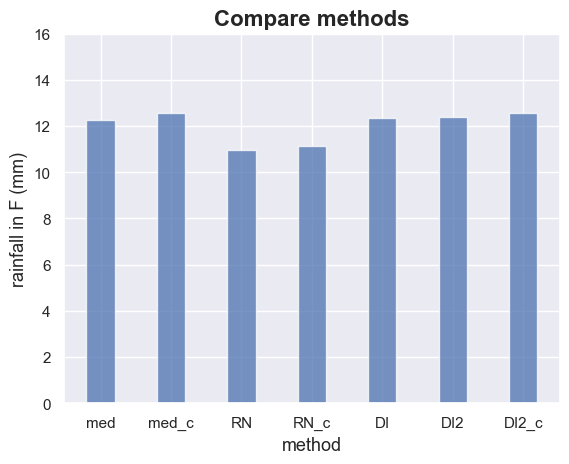

In [16]:
# create an array with all the results
results = np.array([po_mm, po_mmc, po_rn, po_rnc, po_di1, po_di2, po_di2c])
plt.bar(range(len(results)), results, width=0.4, alpha=.75)
plt.title('Compare methods', fontsize=16, weight='bold')
plt.xlabel('method', fontsize=13)
plt.xticks(range(len(results)), ['med', 'med_c', 'RN', 'RN_c', 'DI',
                                 'DI2', 'DI2_c'])
plt.ylim((0, 16))
plt.ylabel('rainfall in F (mm)', fontsize=13)

plt.savefig('Ex1_compare_methods.png', dpi=300)

In [17]:
# convert the array of results in a data frame
results = pd.DataFrame(np.transpose(results),
                       index=['po_mm', 'po_mmc', 'po_rn', 'po_rnc', 'po_di1', 'po_di2', 'po_di2c'])
results = results.transpose()
print(f"Comparison of all methods:\n{results}")
# export results as a csv
results.to_csv('Ex1_compare methods.csv', index=False, float_format='%.1f')
print("Results exported to '../output/Ex1_compare methods.csv'")

Comparison of all methods:
   po_mm  po_mmc      po_rn     po_rnc     po_di1     po_di2    po_di2c
0  12.26  12.575  10.938378  11.110048  12.333644  12.382834  12.539028


Results exported to '../output/Ex1_compare methods.csv'


### Spatial Interpolation: Creating Precipitation Maps
**Exciting Part Alert!** 🎉 Now we're going to create actual precipitation maps! This is where coding becomes really powerful - we can visualise our results across an entire area, not just at single points.

**What we'll do:**
- Create a function that can interpolate rainfall at any point
- Apply this function to a grid of points
- Generate a beautiful precipitation map

**Why this matters:** In real hydrological work, you often need to estimate rainfall across entire watersheds, not just at individual points. This is exactly how modern hydrological software works!

We'll create a Python function that performs Inverse Distance Weighting (IDW) interpolation. Functions are like reusable tools - once you create one, you can use it over and over again!

In [18]:
def IDW(x, y, stnX, stnY, stnP, b=-2):
    """Interpolate by the inverse distance weighted method

    **Coding Tip:** This is your first function! Functions are like recipes - you give them ingredients (parameters) and they give you back a result. Once you understand this pattern, you can create functions for almost anything!

    **What this function does:** Takes a point (x,y) and estimates rainfall there based on nearby stations.

    Parameters:
    ----------
    x:       float. Coordinate X of the target point
    y:       float. Coordinate Y of the target point
    stnX:    Series. Coordinates X of the gauges
    stnY:    Series. Coordinates Y of the gauges
    stnP:    Series. Observed precipitation in the gauges
    b:       int. Exponent in the inverse distance (default -2)

    Returns:
    --------
    p:       float. Precipitation interpolated for point (x, y)
    """

    # distance to the target point
    distX = x - stnX                    # distance along the x axis
    distY = y - stnY                    # distance along the y axis
    dist = np.sqrt(distX**2 + distY**2)  # total distance
    # inverse of the distance
    idw = dist**b
    # interpolate
    p = np.sum(idw / np.sum(idw) * stnP)

    return round(p, 1)

**Testing Our Function**
Let's test our function on point F to make sure it works correctly. This is a great coding practice - always test your functions before using them extensively!

In [19]:
# check the function in point F
result = IDW(data1.loc['F', 'X'], data1.loc['F', 'Y'], data1_['X'], data1_['Y'],
             data1_['p'], b=-2)
print(f"Test result for point F: {result} mm")

Test result for point F: 12.4 mm


**Creating a Grid for Interpolation**
Now the exciting part! We'll create a grid of points and apply our function to each one. This is how we generate a complete precipitation map.v
**Coding Tip:** This is where loops become powerful - we can apply the same calculation to hundreds of points automatically!

In [20]:
# Coordinates X and Y of the grid
xo, xf = 382200, 390200
X = np.arange(xo, xf, 100)
yo, yf = 4771400, 4779400
Y = np.arange(yo, yf, 100)

**Building the Precipitation Map**
We'll create an empty array to store our results, then fill it with interpolated values. This is a common pattern in scientific computing!


In [21]:
# create empty map (zeros) with the dimensions of 'X' and 'Y'
pcp = np.zeros((len(X), len(Y)))

**The Magic Loop!**
This nested loop applies our IDW function to every point in the grid. Don't worry if it takes a moment - we're doing hundreds of calculations!

interpolate rainfall in each cell of the grid
for i, y in enumerate(Y[::-1]):  # important to invert the position of 'Y'
    for j, x in enumerate(X):
        pcp[i, j] = IDW(x, y, data1_.X, data1_.Y, data1_.p, b=-2)
print(f"Precipitation map created with shape: {pcp.shape}")

**Visualising Our Results**

Now for the most rewarding part - creating a beautiful visualization! This is where all our coding work pays off with a professional-looking map.

**Coding Tip:** Visualization is crucial in scientific work. A good plot can communicate more than pages of numbers!

Precipitation map saved as 'Ex1_precipitation_map.png'


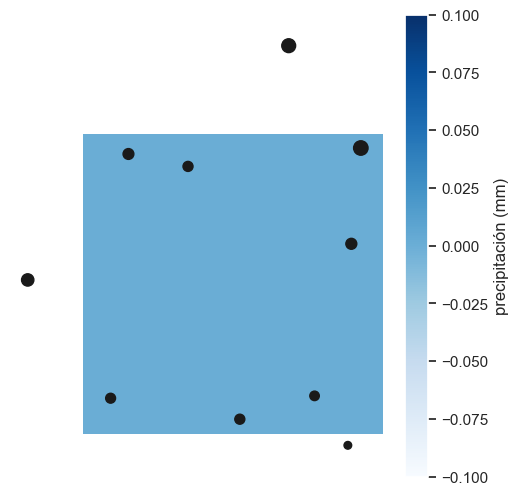

In [22]:
# plot with stations and interpolated precipitation map
# -----------------------------------------------------------------
# configuration
plt.figure(figsize=(6, 6))
plt.axis('equal')
plt.axis('off')
# mapa interpolado
pmap = plt.imshow(pcp, extent=[xo, xf, yo, yf], cmap='Blues')
cb = plt.colorbar(pmap)
cb.set_label('precipitación (mm)', rotation=90, fontsize=12)
# puntos con las estaciones
plt.scatter(data1_.X, data1_.Y, c='k', s=data1_.p**3/30)
plt.savefig('Ex1_precipitation_map.png', dpi=300)
print("Precipitation map saved as 'Ex1_precipitation_map.png'")